In [1]:
import pandas as pd

df = pd.read_excel("AirQualityUCI.xlsx")

df = df.applymap(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)

df.to_csv("AirQualityUCI.csv", index=False)

C:\Users\grabm\AppData\Local\Temp\ipykernel_23912\2708161951.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace(',', '.') if isinstance(x, str) else x)


In [2]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
    df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')

df.to_csv("AirQualityUCI.csv", index=False)

In [3]:
import pandas as pd

df = pd.read_csv("AirQualityUCI.csv", na_values=-200)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,10/03/2004,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,10/03/2004,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,10/03/2004,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,10/03/2004,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [4]:
import numpy as np

types = [
    ("Date", "U10"),
    ("Time", "U8"),
    ("CO_GT", "float64"),
    ("PT08_S1_CO", "float64"),
    ("NMHC_GT", "float64"),
    ("C6H6_GT", "float64"),
    ("PT08_S2_NMHC", "float64"),
    ("NOx_GT", "float64"),
    ("PT08_S3_NOx", "float64"),
    ("NO2_GT", "float64"),
    ("PT08_S4_NO2", "float64"),
    ("PT08_S5_O3", "float64"),
    ("T", "float64"),
    ("RH", "float64"),
    ("AH", "float64")
]

data = np.genfromtxt(
    "AirQualityUCI.csv",
    delimiter=",",
    dtype=types,
    names=True,
    missing_values=["-200", "nan"],
    filling_values=np.nan,
    encoding="utf-8"
)
print(data[:5])

[('10/03/2004', '18:00:00', 2.6, 1360.  , 150., 11.88172349, 1045.5 , 166., 1056.25, 113., 1692.  , 1267.5 , 13.5999999 , 48.87500095, 0.75775383)
 ('10/03/2004', '19:00:00', 2. , 1292.25, 112.,  9.39716489,  954.75, 103., 1173.75,  92., 1558.75,  972.25, 13.29999995, 47.69999981, 0.72548745)
 ('10/03/2004', '20:00:00', 2.2, 1402.  ,  88.,  8.99781687,  939.25, 131., 1140.  , 114., 1554.5 , 1074.  , 11.9000001 , 53.97500038, 0.75023907)
 ('10/03/2004', '21:00:00', 2.2, 1375.5 ,  80.,  9.22879642,  948.25, 172., 1092.  , 122., 1583.75, 1203.25, 11.        , 60.        , 0.78671253)
 ('10/03/2004', '22:00:00', 1.6, 1272.25,  51.,  6.51822367,  835.5 , 131., 1205.  , 116., 1490.  , 1110.  , 11.1500001 , 59.57500076, 0.78879423)]


In [5]:
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df = df.set_index("Datetime")
df_interp = df.interpolate(method="time")

print(df_interp.isna().sum())

print(df_interp.head())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64
                           Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  \
Datetime                                                                   
2004-03-10 18:00:00  10/03/2004  18:00:00     2.6      1360.00     150.0   
2004-03-10 19:00:00  10/03/2004  19:00:00     2.0      1292.25     112.0   
2004-03-10 20:00:00  10/03/2004  20:00:00     2.2      1402.00      88.0   
2004-03-10 21:00:00  10/03/2004  21:00:00     2.2      1375.50      80.0   
2004-03-10 22:00:00  10/03/2004  22:00:00     1.6      1272.25      51.0   

                      C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  \
Datetime                                                                        
2004-03

C:\Users\grabm\AppData\Local\Temp\ipykernel_23912\3382159692.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interp = df.interpolate(method="time")


In [6]:
from datetime import datetime

for name in data.dtype.names[2:]:
    data[name][data[name] == -200] = np.nan

datetime_strs = np.char.add(data["Date"], " ")
datetime_strs = np.char.add(datetime_strs, data["Time"])
datetimes = np.array([datetime.strptime(dt, "%d/%m/%Y %H:%M:%S") for dt in datetime_strs])

time_seconds = np.array([(dt - datetimes[0]).total_seconds() for dt in datetimes])

data_interp = {}
for name in data.dtype.names[2:]:
    y = data[name]
    isnan = np.isnan(y)
    if np.any(~isnan):
        interpolated = np.interp(time_seconds, time_seconds[~isnan], y[~isnan])
    else:
        interpolated = y
    data_interp[name] = interpolated

for name, col in data_interp.items():
    print(f"{name}: {np.isnan(col).sum()} NaNs")

print("\nПерші 5 рядків (інтерпольовані):")
for i in range(5):
    print(f"{datetimes[i]} | " + " | ".join(f"{data_interp[name][i]:.2f}" for name in data_interp))

COGT: 0 NaNs
PT08S1CO: 0 NaNs
NMHCGT: 0 NaNs
C6H6GT: 0 NaNs
PT08S2NMHC: 0 NaNs
NOxGT: 0 NaNs
PT08S3NOx: 0 NaNs
NO2GT: 0 NaNs
PT08S4NO2: 0 NaNs
PT08S5O3: 0 NaNs
T: 0 NaNs
RH: 0 NaNs
AH: 0 NaNs

Перші 5 рядків (інтерпольовані):
2004-03-10 18:00:00 | 2.60 | 1360.00 | 150.00 | 11.88 | 1045.50 | 166.00 | 1056.25 | 113.00 | 1692.00 | 1267.50 | 13.60 | 48.88 | 0.76
2004-03-10 19:00:00 | 2.00 | 1292.25 | 112.00 | 9.40 | 954.75 | 103.00 | 1173.75 | 92.00 | 1558.75 | 972.25 | 13.30 | 47.70 | 0.73
2004-03-10 20:00:00 | 2.20 | 1402.00 | 88.00 | 9.00 | 939.25 | 131.00 | 1140.00 | 114.00 | 1554.50 | 1074.00 | 11.90 | 53.98 | 0.75
2004-03-10 21:00:00 | 2.20 | 1375.50 | 80.00 | 9.23 | 948.25 | 172.00 | 1092.00 | 122.00 | 1583.75 | 1203.25 | 11.00 | 60.00 | 0.79
2004-03-10 22:00:00 | 1.60 | 1272.25 | 51.00 | 6.52 | 835.50 | 131.00 | 1205.00 | 116.00 | 1490.00 | 1110.00 | 11.15 | 59.58 | 0.79


In [7]:
df_numeric = df_interp.select_dtypes(include=["number"])

df_norm = (df_numeric - df_numeric.min()) / (df_numeric.max() - df_numeric.min())

print("Нормовані дані:")
print(df_norm.head())

Нормовані дані:
                       CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
Datetime                                                                        
2004-03-10 18:00:00  0.211864     0.511849  0.120981  0.184498       0.361737   
2004-03-10 19:00:00  0.161017     0.463196  0.088832  0.145428       0.312167   
2004-03-10 20:00:00  0.177966     0.542011  0.068528  0.139148       0.303701   
2004-03-10 21:00:00  0.177966     0.522980  0.061760  0.142780       0.308617   
2004-03-10 22:00:00  0.127119     0.448833  0.037225  0.100156       0.247030   

                      NOx(GT)  PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  \
Datetime                                                              
2004-03-10 18:00:00  0.111036      0.311024  0.328694      0.513040   
2004-03-10 19:00:00  0.068382      0.360796  0.266509      0.453125   
2004-03-10 20:00:00  0.087339      0.346500  0.331655      0.451214   
2004-03-10 21:00:00  0.115098      0.326168  0.355345      0.

In [8]:
norm_data = {}
for name, col in data_interp.items():
    col_min = np.nanmin(col)
    col_max = np.nanmax(col)
    norm = (col - col_min) / (col_max - col_min)
    norm_data[name] = norm
print("Нормовані значення (перші 5):")
for i in range(5):
    print(" | ".join(f"{norm_data[name][i]:.2f}" for name in norm_data))

Нормовані значення (перші 5):
0.21 | 0.51 | 0.12 | 0.18 | 0.36 | 0.11 | 0.31 | 0.33 | 0.51 | 0.45 | 0.33 | 0.50 | 0.28
0.16 | 0.46 | 0.09 | 0.15 | 0.31 | 0.07 | 0.36 | 0.27 | 0.45 | 0.33 | 0.33 | 0.48 | 0.26
0.18 | 0.54 | 0.07 | 0.14 | 0.30 | 0.09 | 0.35 | 0.33 | 0.45 | 0.37 | 0.30 | 0.56 | 0.28
0.18 | 0.52 | 0.06 | 0.14 | 0.31 | 0.12 | 0.33 | 0.36 | 0.46 | 0.43 | 0.28 | 0.64 | 0.29
0.13 | 0.45 | 0.04 | 0.10 | 0.25 | 0.09 | 0.37 | 0.34 | 0.42 | 0.39 | 0.28 | 0.63 | 0.30


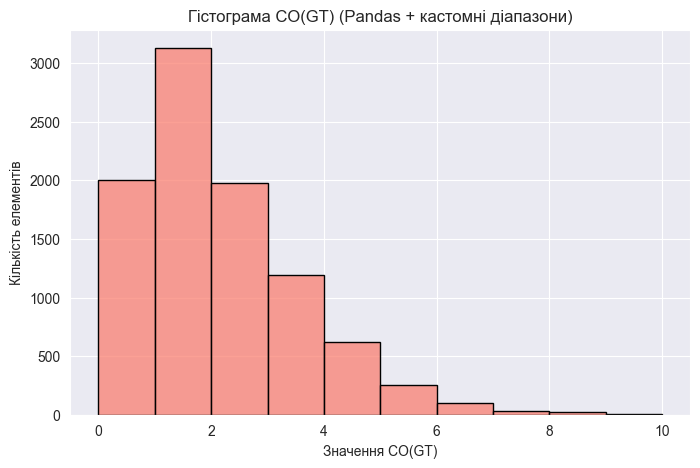

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

co_series = df_interp["CO(GT)"]

custom_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.figure(figsize=(8, 5))
sns.histplot(co_series, bins=custom_bins, kde=False, edgecolor="black", color="salmon")
plt.title("Гістограма CO(GT) (Pandas + кастомні діапазони)")
plt.xlabel("Значення CO(GT)")
plt.ylabel("Кількість елементів")
plt.grid(True)
plt.show()

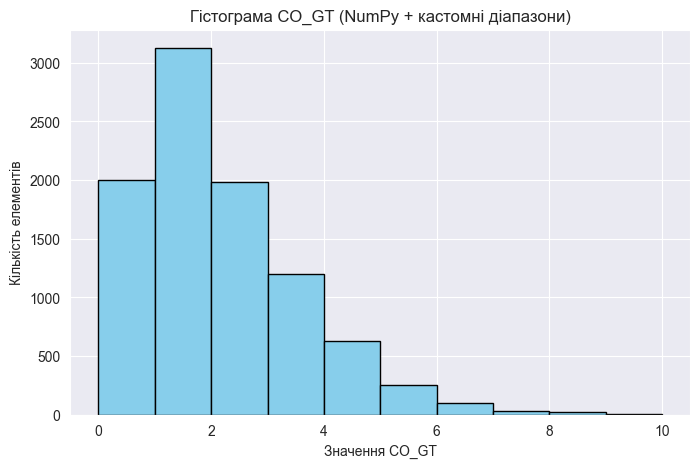

In [10]:
co_array = data_interp["COGT"]

custom_bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.figure(figsize=(8, 5))
plt.hist(co_array, bins=custom_bins, edgecolor='black', color='skyblue')
plt.title("Гістограма CO_GT (NumPy + кастомні діапазони)")
plt.xlabel("Значення CO_GT")
plt.ylabel("Кількість елементів")
plt.grid(True)
plt.show()


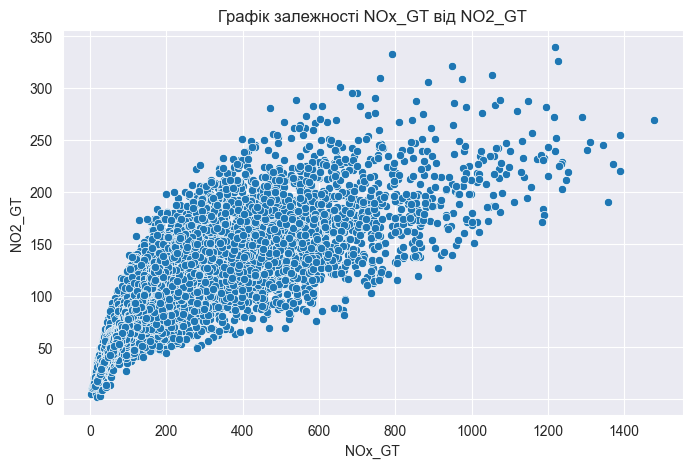

In [11]:
x = df_interp['NOx(GT)']
y = df_interp['NO2(GT)']

plt.figure(figsize=(8, 5))
sns.scatterplot(x=x, y=y)
plt.title("Графік залежності NOx_GT від NO2_GT")
plt.xlabel("NOx_GT")
plt.ylabel("NO2_GT")
plt.grid(True)
plt.show()

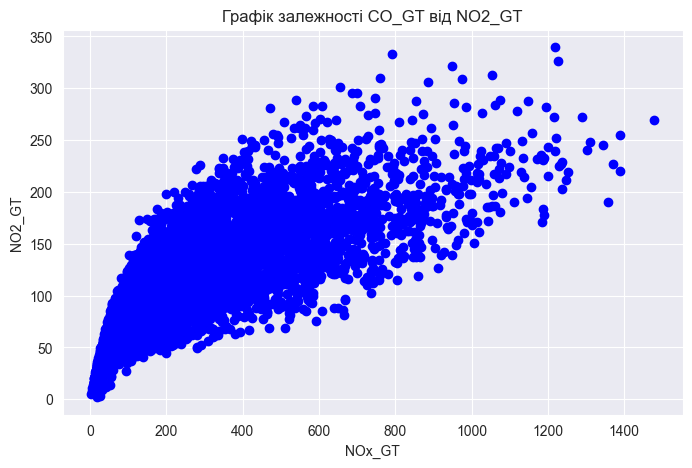

In [12]:
x = data_interp['NOxGT']
y = data_interp['NO2GT']

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue')
plt.title("Графік залежності CO_GT від NO2_GT")
plt.xlabel("NOx_GT")
plt.ylabel("NO2_GT")
plt.grid(True)
plt.show()

In [13]:
from scipy.stats import pearsonr, spearmanr

x = df_interp['NOx(GT)']
y = df_interp['NO2(GT)']

pearson_corr, _ = pearsonr(x, y)
print("Коефіцієнт Пірсона:", pearson_corr)

spearman_corr, _ = spearmanr(x, y)
print("Коефіцієнт Спірмена:", spearman_corr)

Коефіцієнт Пірсона: 0.7630961519572135
Коефіцієнт Спірмена: 0.8195243848784577


In [14]:
x = data_interp['NOxGT']
y = data_interp['NO2GT']

pearson_corr, _ = pearsonr(x, y)
print("Коефіцієнт Пірсона:", pearson_corr)

spearman_corr, _ = spearmanr(x, y)
print("Коефіцієнт Спірмена:", spearman_corr)

Коефіцієнт Пірсона: 0.7630961519572135
Коефіцієнт Спірмена: 0.8195239278598991


In [15]:
from sklearn.preprocessing import OneHotEncoder

time_column = df_interp[['Time']]

encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(time_column)

encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Time']))

print("One Hot Encoded дані:")
print(encoded_df.head())

One Hot Encoded дані:
   Time_00:00:00  Time_01:00:00  Time_02:00:00  Time_03:00:00  Time_04:00:00  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   Time_05:00:00  Time_06:00:00  Time_07:00:00  Time_08:00:00  Time_09:00:00  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   ...  Time_14:

In [16]:
time_strings = data["Time"]

# Парсимо години (наприклад, '18:00:00' → 18)
hours = np.array([
    int(t.split(':')[0]) if t and ':' in t else -1
    for t in time_strings
])

hours_reshaped = hours.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(hours_reshaped)

print("One Hot Encoded перші 5 рядків:\n", one_hot_encoded[:5])

One Hot Encoded перші 5 рядків:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


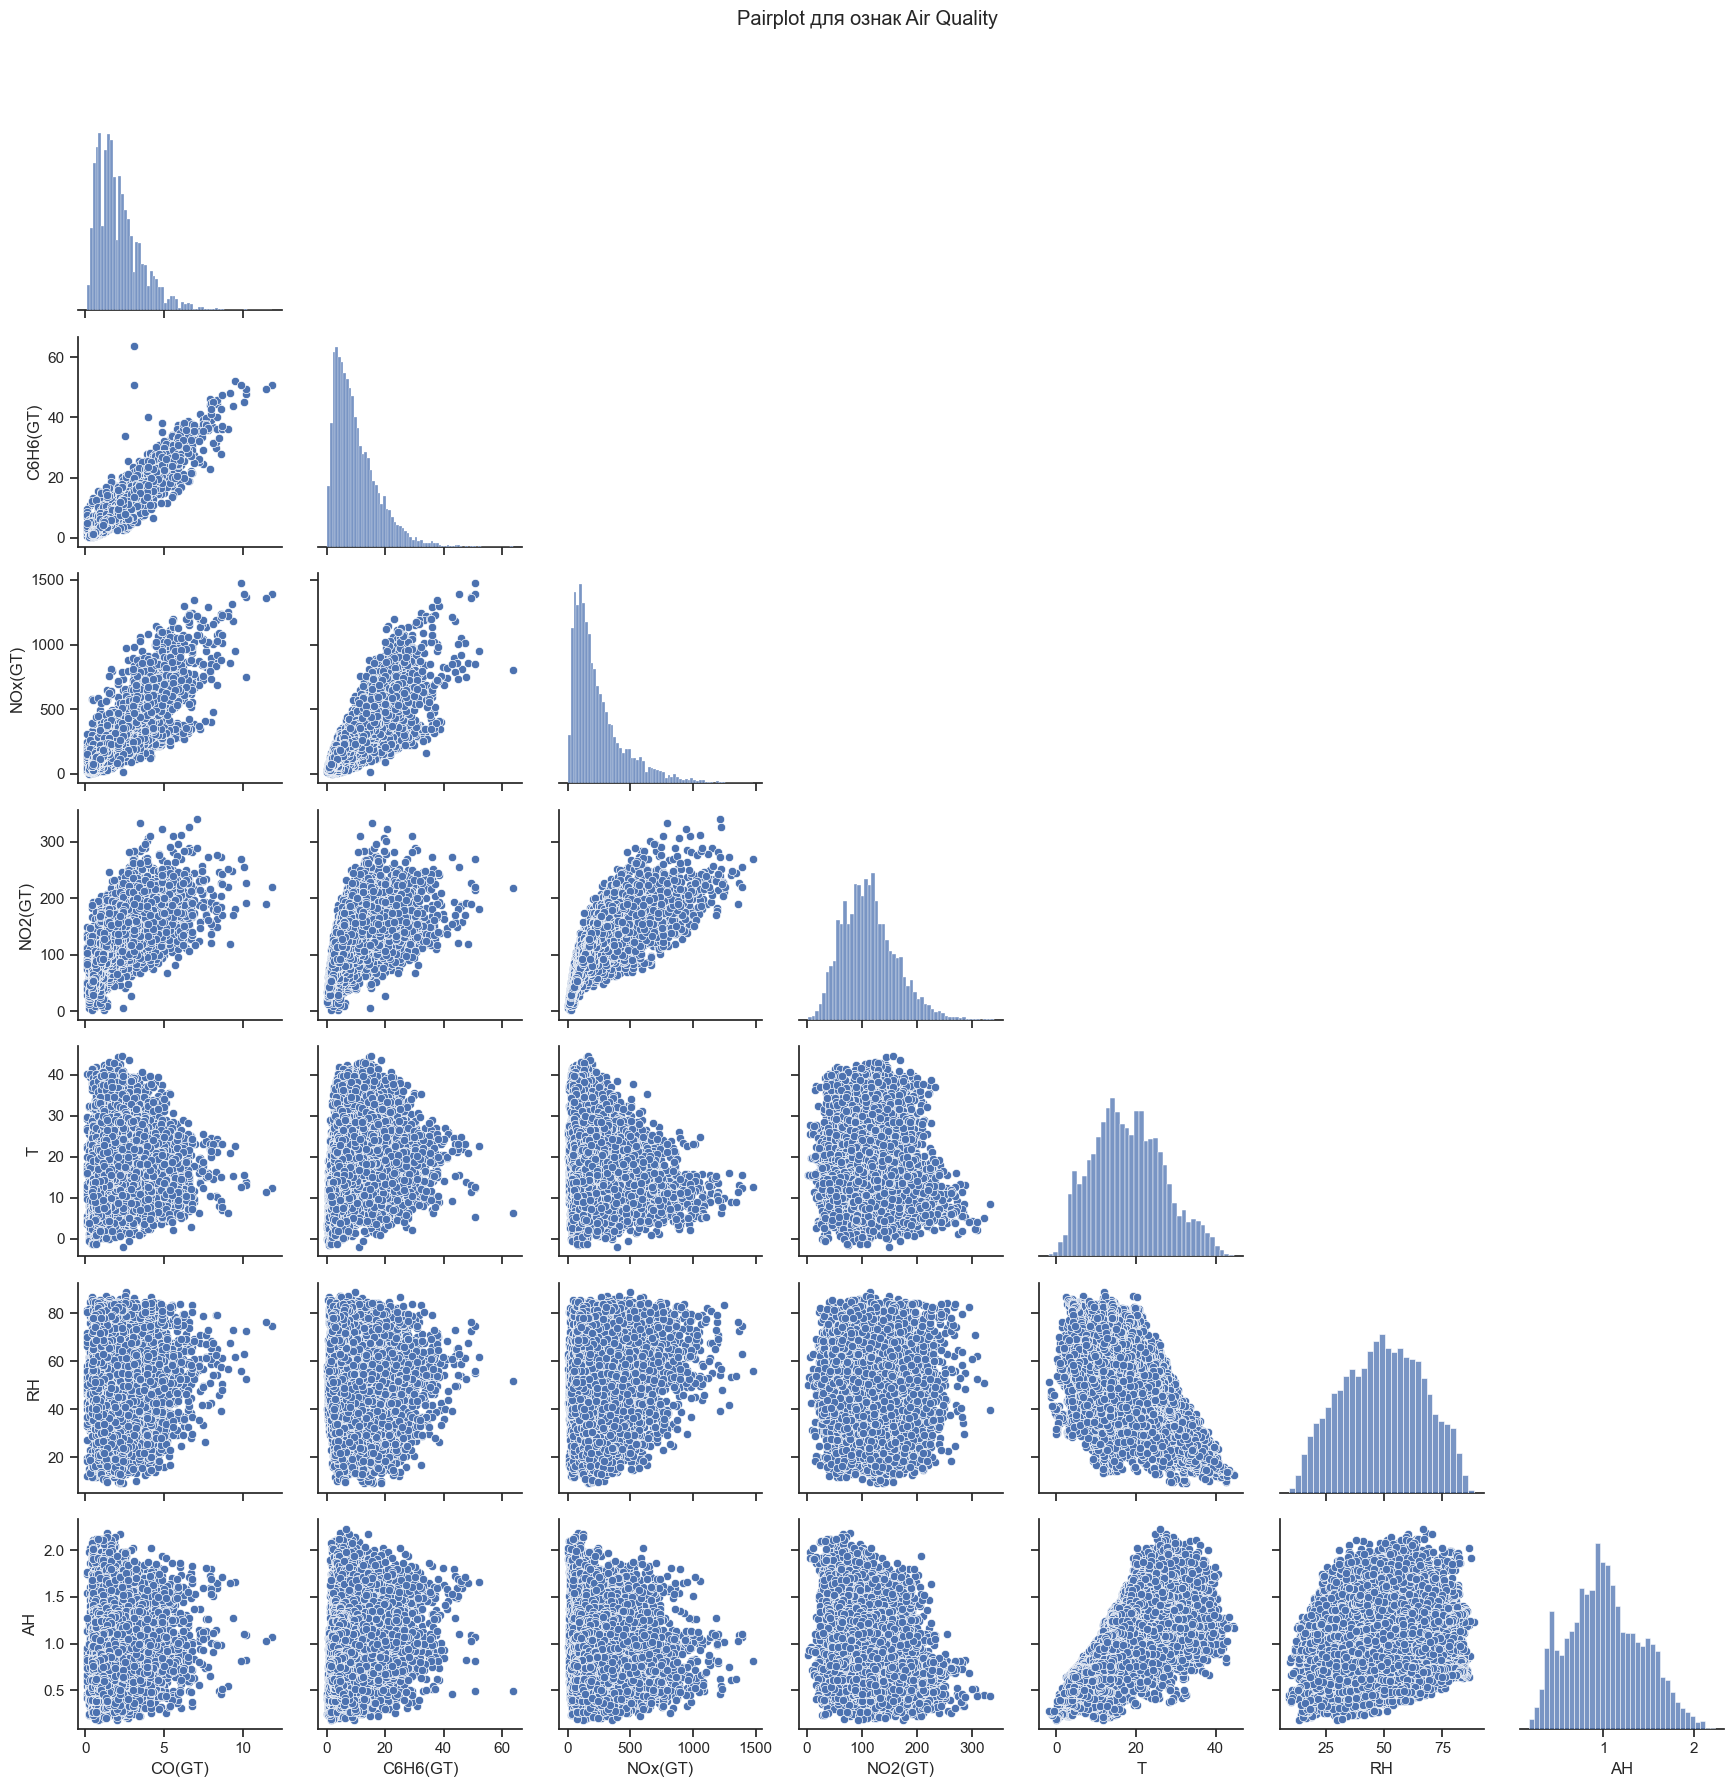

In [17]:
selected_features = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH", "AH"]

sns.set(style="ticks", color_codes=True)
sns.pairplot(df[selected_features], diag_kind="hist", corner=True)
plt.suptitle("Pairplot для ознак Air Quality", y=1.02)
plt.tight_layout()
plt.show()

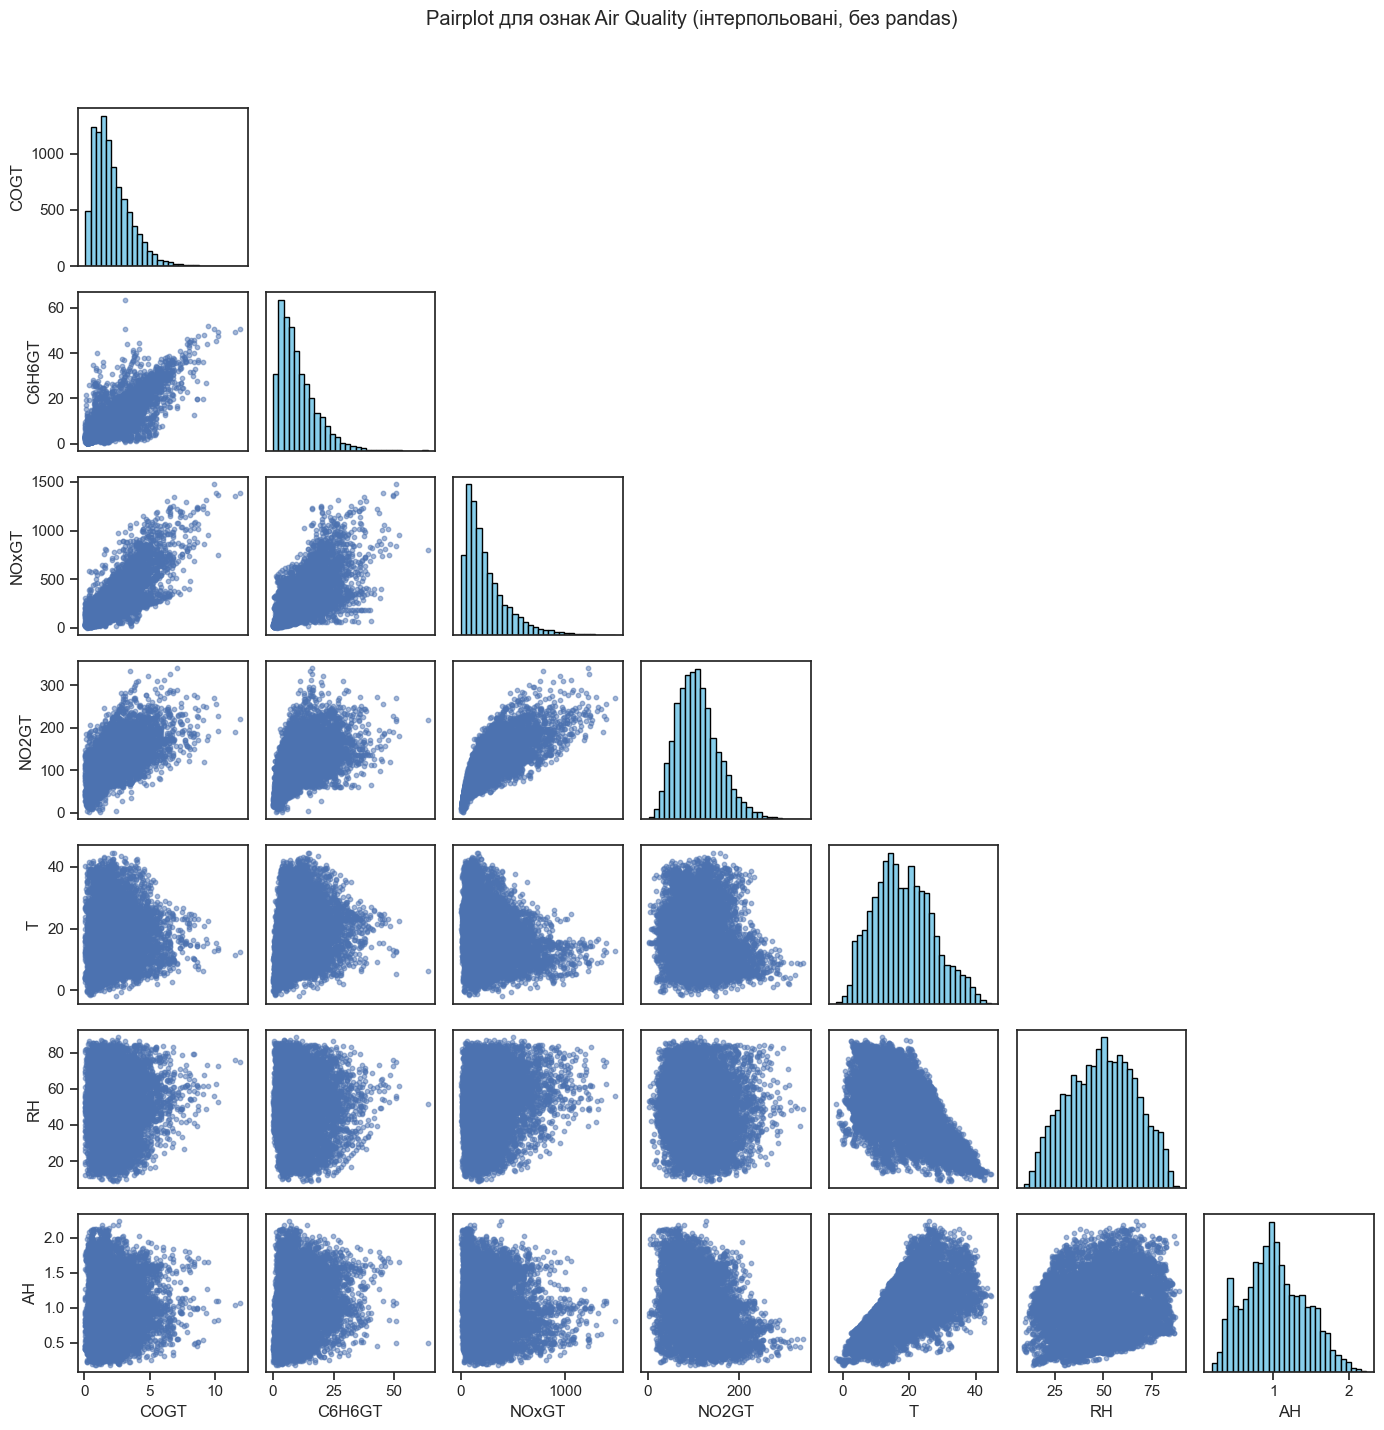

In [18]:
selected_features = ["COGT", "C6H6GT", "NOxGT", "NO2GT", "T", "RH", "AH"]
num_features = len(selected_features)

data_matrix = np.vstack([data_interp[feat] for feat in selected_features]).T

fig, axes = plt.subplots(num_features, num_features, figsize=(14, 14))
fig.suptitle("Pairplot для ознак Air Quality (інтерпольовані, без pandas)", y=1.02)

for i in range(num_features):
    for j in range(num_features):
        ax = axes[i, j]
        if i < j:
            ax.set_visible(False)
        elif i == j:
            ax.hist(data_matrix[:, i], bins=30, color="skyblue", edgecolor="black")
        else:
            ax.scatter(data_matrix[:, j], data_matrix[:, i], alpha=0.5, s=10)

        if i == num_features - 1:
            ax.set_xlabel(selected_features[j])
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(selected_features[i])
        else:
            ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()